# 한국은행 금융안정보고서 기반 거시 금융 리스크 QA 챗봇

**종합 프로젝트** (08_LLM_Text_Anayze 과정 Day 01~03 내용 종합)

## 파이프라인

```
[PDF 보고서 수집]
      ↓ PyPDF2로 텍스트 추출
[텍스트 전처리 & PII 마스킹]
      ↓ 정규식 마스킹 + RecursiveCharacterTextSplitter
[Vector DB 저장]
      ↓ ChromaDB + OpenAIEmbeddings
[RAG QA Chain 구축]
      ↓ create_retrieval_chain + 모르는 내용 환각 방지
[최종 출력]
      ↓ 면책 문구 + 토큰 비용 추정
```

## 사용 데이터
`Mini_Project` 폴더 내 한국은행 금융안정보고서(2026년 6월) 관련 PDF 중 가계부채, 자영업자 대출, 부동산 PF, 시장금리 관련 주제를 다루는 문서 일부를 사용한다.

## 목차
1. 환경설정
2. Step1. 데이터 준비 (PDF 로드)
3. Step2. 텍스트 전처리 & PII 마스킹
4. Step3. 청킹 (Chunking)
5. Step4. 임베딩 & Vector DB 저장
6. Step5. RAG QA 챗봇 연결
7. Step6. 토큰 비용 추정 함수
8. Step7. 검증 & 테스트
9. 결론 및 고려사항
10. 개선: 검색 품질 개선 (Query 분해 + MMR)
11. 개선: 검색 정확도 (LLM 재랭킹)
12. 개선: 데이터 품질 (표 추출)
13. 종합 정리: 남은 개선 과제 (범용성 / 신뢰성 / 평가)
14. 실전 사용: 질문-답변 인터페이스
15. app.py (Streamlit) 실행 가이드


## 1. 환경설정

필요한 라이브러리를 설치하고 OpenAI API 키를 설정한다.
이 노트북은 `Mini_Project` 폴더 안에서 실행하는 것을 전제로 하며, 같은 폴더의 PDF 파일들을 상대경로로 읽는다.

In [56]:
# UV 사용중으로 uv add로 대체함

# !pip install openai tiktoken PyPDF2 -q
# !pip install langchain langchain_community langchain_openai langchain_text_splitters langchain-classic chromadb -q
# !pip install pdfplumber -q

In [57]:
import os

# 이미 환경변수에 키가 설정되어 있지 않다면 아래에 본인의 OpenAI API 키를 입력한다
if not os.getenv('OPENAI_API_KEY'):
    os.environ['OPENAI_API_KEY'] = 'YOUR_OPENAI_API_KEY'

print('API 키 설정 여부 :', bool(os.getenv('OPENAI_API_KEY')))

API 키 설정 여부 : True


In [58]:
import re
import PyPDF2
import tiktoken
import pdfplumber

from openai import OpenAI

# NOTE: langchain-community는 향후 sunset 예정이라 DeprecationWarning이 뜨지만
# 현재 버전에서는 정상 동작하므로 무시하고 진행한다.
# (대안: langchain-chroma 패키지의 `from langchain_chroma import Chroma`로 대체 가능)
from langchain_community.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langchain_classic.chains import create_retrieval_chain
from langchain_classic.chains.combine_documents import create_stuff_documents_chain

client = OpenAI()
print('라이브러리 로드 완료')

라이브러리 로드 완료


## 2. Step1. 데이터 준비 (PDF 로드)

**목표** : 분석할 한국은행 금융안정보고서 PDF를 모은다.

가계부채·자영업자 대출·부동산 PF·시장금리 등 다양한 주제와 리스크 성격이 섞이도록 6개 문서를 선택했다.
`PyPDF2`로 각 PDF의 텍스트를 추출하고, 어떤 파일에서 나온 내용인지 알 수 있도록 파일명을 함께 관리한다.

In [59]:
PDF_DIR = '.'  # 노트북과 같은 폴더(Mini_Project)에 PDF가 있다고 가정

pdf_files = [
    '1. 개관 및 종합평가.pdf',
    '2. 금융안정상황.pdf',
    '4. 자영업 구조 변화에 따른 리스크 점검 및 대응방향.pdf',
    '현안1. 시장금리 상승에 따른 금융시스템 안정성 평가.pdf',
    '현안2. 비은행 부문 잠재리스크 점검 및 시사점.pdf',
    '참고3. 상업용부동산 시장 상황과 리스크 점검.pdf',
]

def extract_pdf_text(path):
    """PDF 파일 경로 -> 전체 텍스트 문자열"""
    text = ''
    with open(path, 'rb') as f:
        reader = PyPDF2.PdfReader(f)
        for page in reader.pages:
            text += page.extract_text() or ''
    return text

raw_docs = {}  # {파일명 : 원문 텍스트}
for fname in pdf_files:
    path = os.path.join(PDF_DIR, fname)
    raw_docs[fname] = extract_pdf_text(path)
    print(f'{fname} : {len(raw_docs[fname])}자 추출')

1. 개관 및 종합평가.pdf : 13269자 추출
2. 금융안정상황.pdf : 146656자 추출
4. 자영업 구조 변화에 따른 리스크 점검 및 대응방향.pdf : 43754자 추출
현안1. 시장금리 상승에 따른 금융시스템 안정성 평가.pdf : 37892자 추출
현안2. 비은행 부문 잠재리스크 점검 및 시사점.pdf : 28955자 추출
참고3. 상업용부동산 시장 상황과 리스크 점검.pdf : 7339자 추출


## 3. Step2. 텍스트 전처리 & PII 마스킹

**목표** : LLM에 보내기 전, 개행/공백을 정리하고 민감정보(주민번호, 계좌번호, 휴대폰번호 패턴)를 정규식으로 마스킹한다.

공식 보고서라 실제 개인정보가 나올 가능성은 낮지만, 실서비스에서는 사용자 입력이나 문서에 포함될 수 있는
민감정보를 LLM에 보내기 **전에** 마스킹하는 것이 안전하다는 원칙을 그대로 적용한다.

In [60]:
def clean_text(text):
    """개행/중복 공백 정리"""
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def mask_pii(text):
    """주민번호 / 계좌번호 / 휴대폰번호 패턴 마스킹"""
    # 주민등록번호 뒷자리 마스킹 (예: 951225-1234567 -> 951225-*******)
    text = re.sub(r'(\d{6})-\d{7}', r'\1-*******', text)
    # 계좌번호 마스킹 (예: 123-456-789012 -> 123-456-******)
    text = re.sub(r'(\d{2,6}-\d{2,6})-\d{4,8}', lambda m: m.group(1) + '-' + '*' * 6, text)
    # 휴대폰번호 마스킹 (예: 010-1234-5678 -> 010-****-****)
    text = re.sub(r'(01[016789])-?\d{3,4}-?\d{4}', r'\1-****-****', text)
    return text

clean_docs = {}
for fname, text in raw_docs.items():
    t = clean_text(text)
    t = mask_pii(t)
    clean_docs[fname] = t
    print(f'{fname} : 전처리 후 {len(t)}자')

1. 개관 및 종합평가.pdf : 전처리 후 11933자
2. 금융안정상황.pdf : 전처리 후 125878자
4. 자영업 구조 변화에 따른 리스크 점검 및 대응방향.pdf : 전처리 후 37913자
현안1. 시장금리 상승에 따른 금융시스템 안정성 평가.pdf : 전처리 후 32121자
현안2. 비은행 부문 잠재리스크 점검 및 시사점.pdf : 전처리 후 25125자
참고3. 상업용부동산 시장 상황과 리스크 점검.pdf : 전처리 후 6336자


## 4. Step3. 청킹 (Chunking)

**목표** : 긴 문서를 검색에 적합한 크기로 조각내고, 어느 파일에서 나온 조각인지 `metadata`로 남긴다.

보고서 문장은 비교적 길고 문맥이 이어지므로 `chunk_size=500, chunk_overlap=50` 정도로 설정한다.
(짧은 뉴스 헤드라인 실습보다 청크를 크게 잡아야 문맥이 끊기지 않는다.)

In [61]:
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)

docs = []
for fname, text in clean_docs.items():
    chunks = splitter.split_text(text)
    for chunk in chunks:
        docs.append(Document(page_content=chunk, metadata={'source': fname}))

print('총 청크 수 :', len(docs))
print('\n[예시 청크]')
print(docs[0].page_content[:150])

총 청크 수 : 534

[예시 청크]
개관 및 종합평가 종합평가 :금융시스템은 대체로안정적이나 시장변동성은 확대 대내외 여건(대외) 중동상황 관련영향지속, 국제금융시장 변동성상존 (대내) 국내실물경제의 견조한성장세 , 대외충격의 인플레이션 전이우려 금융 취약성지수 (FVI)(변동) 상승지속 (수준) 장기평


## 5. Step4. 임베딩 & Vector DB 저장

**목표** : 청크를 임베딩해 ChromaDB에 저장하고, 질문과 유사한 조각을 검색할 수 있게 한다.

기존 컬렉션이 남아있으면 계속 누적되므로, 매번 삭제 후 새로 생성한다.

In [62]:
try:
    db.delete_collection()
except NameError:
    pass
except Exception:
    pass

db = Chroma.from_documents(docs, OpenAIEmbeddings(), collection_name='fsr_2026_06')

print('벡터 DB에 저장된 청크 수 :', db._collection.count())

벡터 DB에 저장된 청크 수 : 1068


In [63]:
# 검색 테스트: 벡터 DB가 잘 만들어졌는지 확인
test_query = '가계부채 현황은 어때?'
hits = db.similarity_search(test_query, k=3)

print(f'[테스트 질문] {test_query}\n')
for i, h in enumerate(hits, 1):
    print(f'[{i}] 출처: {h.metadata.get("source")}')
    print(h.page_content[:100], '\n')

[테스트 질문] 가계부채 현황은 어때?

[1] 출처: 2. 금융안정상황.pdf
(안정총괄팀) 이 작성, 이정연 (금융안정기획부장) ᆞ김정호 (안정총괄팀장 )가 검토하였다 . 29 본고에서는 보유주택 수에 따른 가계의 재무 현황, 채무상환능력 및 부실위험 등을 

[2] 출처: 2. 금융안정상황.pdf
(안정총괄팀) 이 작성, 이정연 (금융안정기획부장) ᆞ김정호 (안정총괄팀장 )가 검토하였다 . 29 본고에서는 보유주택 수에 따른 가계의 재무 현황, 채무상환능력 및 부실위험 등을 

[3] 출처: 2. 금융안정상황.pdf
필요가 있다. 가계신용 의 가계는 일반가계를 의미하나 자금순환통계는 소규모 개인사업자 및 가계에 봉사하는 민간비영리단체를 포괄한다. 3 수도권 아파트 매매거래량 (만호): 25년  



## 6. Step5. RAG QA 챗봇 연결

**목표** : 검색기(Retriever)와 LLM을 연결해, 문서에 근거해서만 답하는 챗봇을 만든다.

- `create_retrieval_chain` 방식 사용 (최신 권장 방식)
- 시스템 프롬프트에 "문서에 없으면 모른다고 답하라"는 지시를 명확히 넣어 환각을 방지한다
- 최종 답변에는 항상 면책 문구를 덧붙인다 (LLM이 빠뜨릴 수 있으므로 코드에서 직접 문자열로 덧붙여 100% 보장한다)

In [64]:
DISCLAIMER = (
    '\n\n---\n'
    '본 답변은 한국은행 금융안정보고서(2026년 6월)에 기초하며, '
    '투자/금융 결정의 법적 근거가 될 수 없습니다.'
)

llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)
retriever = db.as_retriever(search_kwargs={'k': 4})

system_prompt = """너는 한국은행 금융안정보고서를 기반으로 답하는 거시 금융 리스크 분석 도우미다.
아래 [문서] 내용만 근거로 답하라.
[문서]에 없는 내용이면 절대 추측하거나 지어내지 말고, 반드시 "자료에서 확인할 수 없습니다"라고만 답하라.
수치나 통계를 인용할 때는 문서에 있는 표현을 그대로 사용하라.

[문서]
{context}"""

prompt = ChatPromptTemplate.from_messages([
    ('system', system_prompt),
    ('human', '{input}')
])

documents_chain = create_stuff_documents_chain(llm=llm, prompt=prompt)
qa_chain = create_retrieval_chain(retriever, documents_chain)

print('QA 챗봇 준비 완료')

QA 챗봇 준비 완료


In [65]:
def ask(question):
    """질문 -> (면책 문구 포함 답변, 출처 파일 목록, 근거 청크 리스트)"""
    res = qa_chain.invoke({'input': question})
    answer = res['answer'] + DISCLAIMER
    sources = sorted(set(d.metadata.get('source', '알수없음') for d in res['context']))
    return answer, sources, res['context']

# 간단 테스트
answer, sources, context_docs = ask('최근 가계부채 및 자영업자 대출 리스크 상황을 요약해줘')
print('[답변]', answer)
print('[출처]', sources)

[답변] 자료에서 확인할 수 없습니다.

---
본 답변은 한국은행 금융안정보고서(2026년 6월)에 기초하며, 투자/금융 결정의 법적 근거가 될 수 없습니다.
[출처] ['1. 개관 및 종합평가.pdf', '4. 자영업 구조 변화에 따른 리스크 점검 및 대응방향.pdf']


## 7. Step6. 토큰 비용 추정 함수

**목표** : 질문/답변마다 호출되는 토큰 수를 세어 예상 비용을 계산한다.

`tiktoken`으로 실제 입력(컨텍스트+질문)과 출력(답변) 토큰 수를 세고,
`gpt-4o-mini` 단가(입력 100만 토큰당 $0.15, 출력 100만 토큰당 $0.60)를 곱해 비용을 추정한다.

In [66]:
enc = tiktoken.get_encoding('cl100k_base')

PRICE_IN, PRICE_OUT = 0.15, 0.60  # gpt-4o-mini, 100만 토큰당 USD

def estimate_cost(input_text, output_text):
    """입력/출력 텍스트 -> (입력토큰수, 출력토큰수, 예상비용 USD)"""
    in_tok = len(enc.encode(input_text))
    out_tok = len(enc.encode(output_text))
    cost = (in_tok / 1e6) * PRICE_IN + (out_tok / 1e6) * PRICE_OUT
    return in_tok, out_tok, cost

print('비용 추정 함수 준비 완료')

비용 추정 함수 준비 완료


## 8. Step7. 검증 & 테스트

**목표** : 여러 질문으로 답변과 출처가 정확한지, 자료에 없는 질문에는 "모른다"고 답하는지 확인한다.

- 질문 1~3: 문서에 있는 내용 (요약형 질문 포함)
- 질문 4: 문서와 무관한 질문 (환각 방지 확인용)

각 질문마다 답변, 출처 파일, 예상 토큰 비용을 함께 출력한다.

In [67]:
questions = [
    '최근 가계부채 및 자영업자 대출 리스크 상황을 요약해줘',
    '부동산 PF 관련 금융기관 연체율 추이는 어때?',
    '시장금리 상승이 금융시스템 안정성에 미치는 영향은?',
    '2026년 노벨 경제학상 수상자는 누구야?',  # 자료에 없는 질문 -> 환각 방지 확인용
]

total_cost = 0.0

for q in questions:
    answer, sources, context_docs = ask(q)
    context_text = '\n'.join(d.page_content for d in context_docs)
    in_tok, out_tok, cost = estimate_cost(context_text + q, answer)
    total_cost += cost

    print('=' * 80)
    print('[질문]', q)
    print('[답변]', answer)
    print('[출처 문서]', sources)
    print(f'[토큰] 입력 {in_tok} / 출력 {out_tok} / 예상비용 ${cost:.5f}')

print('\n총 예상 비용(테스트 질문 4건 기준) : $', round(total_cost, 5))

[질문] 최근 가계부채 및 자영업자 대출 리스크 상황을 요약해줘
[답변] 자료에서 확인할 수 없습니다.

---
본 답변은 한국은행 금융안정보고서(2026년 6월)에 기초하며, 투자/금융 결정의 법적 근거가 될 수 없습니다.
[출처 문서] ['1. 개관 및 종합평가.pdf', '4. 자영업 구조 변화에 따른 리스크 점검 및 대응방향.pdf']
[토큰] 입력 1943 / 출력 77 / 예상비용 $0.00034
[질문] 부동산 PF 관련 금융기관 연체율 추이는 어때?
[답변] 상호금융의 경우 부실채권 정리 지연 등으로 PF 연체율이 2025년 12월 말 기준 24.0%로 높은 수준을 지속하고 있으며, 부실 PF 익스포저 비중도 2024년 9월말 21.7%에서 2025년 12월말 25.3%로 상승하였습니다. 대출 부실은 금융여건 완화 및 금융기관의 부실채권 정리 노력에도 불구하고 충분히 축소되지 않은 채 상환능력 개선 지연 및 대출 금리 상승 영향 등으로 연체율이 다시 상승하거나 장기간 높은 수준에 머무를 가능성이 있습니다. 2024년 9월 이후 연체율 추이를 과거 금리 인하기와 비교해 보면 부동산 PF 부실이 불거졌던 2012년과 유사하게 초반에 일정기간 상승하다가 하락 전환하였으나, 금년 들어 연체율이 다시 상승 전환한 상황입니다.

---
본 답변은 한국은행 금융안정보고서(2026년 6월)에 기초하며, 투자/금융 결정의 법적 근거가 될 수 없습니다.
[출처 문서] ['현안1. 시장금리 상승에 따른 금융시스템 안정성 평가.pdf', '현안2. 비은행 부문 잠재리스크 점검 및 시사점.pdf']
[토큰] 입력 1971 / 출력 434 / 예상비용 $0.00056
[질문] 시장금리 상승이 금융시스템 안정성에 미치는 영향은?
[답변] 시장금리 상승에 따른 단기 금융안정 리스크는 금융불균형 완화 효과가 나타나면서 점차 줄어들 것으로 보입니다. 또한 금리상승 시나리오하에서 금융기관 복원력에 미치는 부정적 영향은 이자이익 증가 등에 힘입어 제한적인 수준에 그칠 것으로 판단됩

## 9. 결론 및 고려사항

### 비용 (토큰)
- 질문 1건당 평균 토큰 수와 비용을 위 Step6/Step7에서 실측했다.
- 실서비스 규모(일 예상 질문 수 x 건당 평균 비용)를 곱하면 일/월 예상 비용을 추정할 수 있다.

### 보안 (민감정보)
- 문서를 벡터 DB에 넣기 전에 정규식으로 주민번호/계좌번호/휴대폰번호를 마스킹했다.
- 실서비스에서는 사용자의 질문에도 같은 마스킹을 적용해, 로그나 LLM 호출에 민감정보가 그대로 남지 않도록 해야 한다.

### 신뢰성 (환각 방지)
- 시스템 프롬프트에 "문서에 없으면 모른다고 답하라"는 지시를 넣고, 관련 없는 질문(노벨 경제학상 질문)으로 실제 동작을 확인했다.
- 답변마다 근거가 된 출처 파일을 함께 제시해, 사용자가 원문을 직접 확인할 수 있게 했다.
- 모든 답변 끝에 면책 문구를 코드로 강제 추가해, LLM이 문구를 누락하는 경우를 방지했다.

### 추가 개선 아이디어
- chunk_size/overlap을 바꿔가며 검색 품질을 비교해본다 (Day 03 실습 참고).
- 키워드 검색(BM25)과 의미 검색을 함께 쓰는 하이브리드 검색을 적용해본다.
- 질문 유형별로 리트리버의 k값을 다르게 조정해본다.


## 10. 개선: 검색 품질 개선 (Query 분해 + MMR)

### 문제 진단
Step7 검증에서 `'최근 가계부채 및 자영업자 대출 리스크 상황을 요약해줘'` 질문에 `'자료에서 확인할 수 없습니다'`가 나왔다.
출처를 보면 `k=4`로 뽑힌 조각이 `1. 개관 및 종합평가.pdf`, `4. 자영업...pdf`에서만 나왔고, 정작 가계부채 상세 내용이 많은
`2. 금융안정상황.pdf`의 관련 조각은 뽑히지 못했다. 원인은 두 가지로 보인다.

1. **질문이 복합 질문이다.** "가계부채" + "자영업자 대출" 두 주제를 한 번에 묻는데, 임베딩 유사도 검색은 질문 문장 전체를 하나의 벡터로 보기 때문에 두 주제 중 한쪽에 치우친 조각만 상위 k개에 뽑히기 쉽다.
2. **k=4가 요약형 질문엔 너무 작다.** 사실 확인형 질문(연체율 추이 등)에는 충분했지만, 여러 섹션에 흩어진 내용을 종합해야 하는 요약형 질문에는 검색 폭이 부족했다.
3. **프롬프트가 과도하게 엄격했다.** "문서에 없으면 모른다"는 지시가 강해서, 관련 조각이 일부만 뽑히고 질문 문구와 정확히 안 맞으면 LLM이 안전하게 "모른다"로 회피해버렸다.

### 개선 방향
- **질문 분해(Query Decomposition)**: 복합 질문을 하위 검색어 여러 개로 나눠 각각 검색한 뒤 합친다.
- **MMR 검색**: 단순 유사도 검색 대신 `max_marginal_relevance_search`로 검색해, 비슷한 조각끼리 중복 검색되는 것을 줄이고 다양한 주제의 조각이 골고루 뽑히게 한다.
- **프롬프트 완화**: "여러 조각을 종합해 요약하는 것은 허용하되, 문서에 전혀 없는 사실은 만들지 마라"로 바꿔, 지나치게 방어적으로 회피하지 않도록 한다.

아래에서 이 세 가지를 반영한 `ask_v2()`를 만들고, 실패했던 질문으로 다시 검증한다.

In [68]:
def expand_query(question, n=3):
    """복합 질문 -> 벡터 검색에 유리한 짧은 하위 검색어 n개 (LLM으로 생성)"""
    prompt = f"""다음 질문에 답하기 위해 벡터DB에서 검색할 하위 검색어를 {n}개 만들어라.
각 검색어는 핵심 키워드 중심의 짧은 구/문장으로 작성하고, 한 줄에 하나씩만 출력하라.
번호, 설명, 따옴표는 붙이지 마라.

질문: {question}"""

    r = client.chat.completions.create(
        model='gpt-4o-mini',
        messages=[{'role': 'user', 'content': prompt}],
        temperature=0)

    lines = [l.strip('-• ').strip() for l in r.choices[0].message.content.split('\n') if l.strip()]
    return lines[:n]

# 테스트
test_q = '최근 가계부채 및 자영업자 대출 리스크 상황을 요약해줘'
print('[원 질문]', test_q)
print('[분해된 하위 검색어]', expand_query(test_q))

[원 질문] 최근 가계부채 및 자영업자 대출 리스크 상황을 요약해줘
[분해된 하위 검색어] ['가계부채 증가 추세 분석', '자영업자 대출 리스크 요인', '금리 인상 영향 평가']


In [69]:
def multi_query_search(question, k_per_query=4, fetch_k=20):
    """원 질문 + 하위 검색어들을 MMR로 각각 검색한 뒤 중복 제거해 병합"""
    sub_queries = expand_query(question)
    all_queries = [question] + sub_queries

    seen = set()
    merged_docs = []
    for q in all_queries:
        hits = db.max_marginal_relevance_search(q, k=k_per_query, fetch_k=fetch_k, lambda_mult=0.5)
        for h in hits:
            key = h.page_content[:50]
            if key not in seen:
                seen.add(key)
                merged_docs.append(h)

    return merged_docs, sub_queries

# 테스트: 실패했던 질문으로 검색 결과 확인
merged_docs, sub_queries = multi_query_search(test_q)
print('[하위 검색어]', sub_queries)
print('[병합된 조각 수]', len(merged_docs))
print('[출처 분포]', sorted(set(d.metadata.get('source') for d in merged_docs)))

[하위 검색어] ['가계부채 증가 추세 분석', '자영업자 대출 리스크 요인', '금리 인상과 대출 상환 부담']
[병합된 조각 수] 15
[출처 분포] ['1. 개관 및 종합평가.pdf', '2. 금융안정상황.pdf', '4. 자영업 구조 변화에 따른 리스크 점검 및 대응방향.pdf', '현안1. 시장금리 상승에 따른 금융시스템 안정성 평가.pdf']


In [70]:
system_prompt_v2 = """너는 한국은행 금융안정보고서를 기반으로 답하는 거시 금융 리스크 분석 도우미다.
아래 [문서]에 있는 내용만 근거로 답하라.
여러 조각에 흩어져 있는 내용이라도 사실관계가 서로 어긋나지 않는다면 종합해서 요약해도 된다.
[문서] 전체를 살펴봐도 관련 내용이 전혀 없을 때만 "자료에서 확인할 수 없습니다"라고 답하라.
수치나 통계를 인용할 때는 문서에 있는 표현을 그대로 사용하라.

[문서]
{context}"""

prompt_v2 = ChatPromptTemplate.from_messages([
    ('system', system_prompt_v2),
    ('human', '{input}')
])

documents_chain_v2 = create_stuff_documents_chain(llm=llm, prompt=prompt_v2)

print('개선된 문서결합 체인 준비 완료')

개선된 문서결합 체인 준비 완료


In [71]:
def ask_v2(question, k_per_query=4):
    """질문 분해 + MMR 검색 + 완화된 프롬프트를 적용한 개선 버전 ask"""
    merged_docs, sub_queries = multi_query_search(question, k_per_query=k_per_query)
    answer = documents_chain_v2.invoke({'input': question, 'context': merged_docs})
    answer = answer + DISCLAIMER
    sources = sorted(set(d.metadata.get('source', '알수없음') for d in merged_docs))
    return answer, sources, merged_docs, sub_queries

# 기존 ask() vs 개선된 ask_v2() 비교
question = '최근 가계부채 및 자영업자 대출 리스크 상황을 요약해줘'

old_answer, old_sources, _ = ask(question)
new_answer, new_sources, _, sub_queries = ask_v2(question)

print('=== 기존 ask() ===')
print('[답변]', old_answer)
print('[출처]', old_sources)

print('\n=== 개선된 ask_v2() ===')
print('[하위 검색어]', sub_queries)
print('[답변]', new_answer)
print('[출처]', new_sources)

=== 기존 ask() ===
[답변] 자료에서 확인할 수 없습니다.

---
본 답변은 한국은행 금융안정보고서(2026년 6월)에 기초하며, 투자/금융 결정의 법적 근거가 될 수 없습니다.
[출처] ['1. 개관 및 종합평가.pdf', '4. 자영업 구조 변화에 따른 리스크 점검 및 대응방향.pdf']

=== 개선된 ask_v2() ===
[하위 검색어] ['가계부채 증가 추세 분석', '자영업자 대출 리스크 요인', '금리 인상과 대출 상환 부담']
[답변] 최근 가계부채 및 자영업자 대출 리스크 상황은 다음과 같습니다.

1. **가계부채 현황**: 2026년 1/4분기말 기준 가계대출은 1,865.8조원으로, 가계부채 중 93.6%를 차지하고 있습니다. 가계신용은 완만한 증가세를 보였으나, 다주택자 양도소득세 중과 유예 종료에 따른 주택매매 증가 등으로 5월 이후 대출 증가폭이 확대되었습니다.

2. **자영업자 대출 현황**: 자영업자의 금융부채는 2015년 1/4분기말 399.8조원에서 2026년 1/4분기말 1,095.5조원으로 증가하였으며, 자영업자 차주는 2023년 3/4분기말 325.9만명으로 정점을 찍은 후 감소세를 보이고 있습니다. 자영업자 대출의 36.7%가 비은행 대출로, 이 중 88.8%가 상호금융 및 저축은행 등에서 차입한 것으로 나타났습니다.

3. **리스크 요인**: 자영업자의 상환여력 약화와 고연령 자영업자의 부실위험이 증가하고 있으며, 취약차주 중심의 대출 연체율 상승이 우려되고 있습니다. 금융여건이 긴축적으로 전환될 경우 이러한 잠재 리스크가 현실화될 가능성이 있습니다.

4. **정책 대응**: 한국은행은 금융시스템 안정을 유지하기 위해 대내외 불확실성을 점검하고, 필요 시 정부와 협력하여 시장 안정화 조치를 실시할 계획입니다. 자영업자 대출 심사를 정교화하고, 정책금융과 보증지원의 방향성을 생산적인 분야로 유도하는 등의 조치를 고려하고 있습니다. 

이러한 상황은 금융안정 리스크를 초래할 수 있으며, 정책당국은 지속

In [72]:
# 개선된 버전으로 Step7의 질문 4개를 다시 검증
# (마지막 질문은 여전히 '모른다'고 답해야 정상 - 환각 방지가 유지되는지 확인)

total_cost_v2 = 0.0

for q in questions:
    answer, sources, merged_docs, sub_queries = ask_v2(q)
    context_text = '\n'.join(d.page_content for d in merged_docs)
    in_tok, out_tok, cost = estimate_cost(context_text + q, answer)
    total_cost_v2 += cost

    print('=' * 80)
    print('[질문]', q)
    print('[하위 검색어]', sub_queries)
    print('[답변]', answer)
    print('[출처 문서]', sources)
    print(f'[토큰] 입력 {in_tok} / 출력 {out_tok} / 예상비용 ${cost:.5f}')

print('\n총 예상 비용(개선 버전, 질문 4건 기준) : $', round(total_cost_v2, 5))
print('※ 하위 검색어 생성에 LLM 호출이 추가되어, 기존 ask() 대비 질문당 비용/응답시간이 늘어난다.')

[질문] 최근 가계부채 및 자영업자 대출 리스크 상황을 요약해줘
[하위 검색어] ['가계부채 증가 추세 분석', '자영업자 대출 리스크 요인', '금리 인상 영향 평가']
[답변] 최근 가계부채 및 자영업자 대출 리스크 상황은 다음과 같습니다.

1. **가계부채 현황**: 2026년 1/4분기말 기준 가계부채는 1,865.8조원으로, 가계부채 중 93.6%가 가계대출에 해당합니다. 가계대출은 1/4분기 중 완만한 증가세를 보였으나, 다주택자 양도소득세 중과 유예 종료를 앞두고 수도권을 중심으로 주택매매가 증가하면서 5월 이후 대출 증가폭이 크게 확대되었습니다.

2. **자영업자 대출 현황**: 자영업자의 금융부채는 2015년 1/4분기 말 399.8조원에서 2026년 1/4분기말 1,095.5조원으로 증가하였으며, 자영업자 차주는 2023년 3/4분기 말 325.9만명으로 정점을 찍은 후 감소세를 보이고 있습니다. 자영업자 대출의 36.7%는 비은행 대출로, 이 중 88.8%가 상호금융 및 저축은행 등에서 차입한 것으로 나타났습니다.

3. **리스크 요인**: 자영업자의 상환여력이 약화되고, 고연령 자영업자의 부실 위험이 비은행권을 중심으로 전이될 가능성이 있습니다. 또한, 취약차주 중심의 대출 연체율 상승이 금융안정 리스크로 이어질 수 있으며, 향후 소득 여건 개선이 지연되고 금융 여건이 긴축적으로 전환될 경우 이러한 잠재 리스크가 현실화될 가능성에 유의해야 합니다.

4. **정책 대응**: 한국은행은 금융시스템 안정을 유지하기 위해 대내외 불확실성을 점검하고, 필요 시 정부와 협력하여 시장 안정화 조치를 실시할 계획입니다. 특히, 자영업자 대출 심사를 정교화하고, 정책금융과 보증 지원을 통해 생산적인 분야로 자금이 이동하도록 유도할 필요가 있습니다. 

이러한 상황을 종합적으로 고려할 때, 가계부채와 자영업자 대출의 리스크는 여전히 높은 수준이며, 정책적 대응이 필요합니다.

---
본 답변은 한국은행 금융안정보고서(2026년 6월)에 기초하며, 투

### 개선 결과 정리
- 실패했던 요약형 질문(`가계부채 및 자영업자 대출 리스크`)이 `ask_v2()`에서는 여러 파일(`2. 금융안정상황.pdf`, `4. 자영업...pdf` 등)의 조각을 함께 근거로 답하는지 확인한다.
- 마지막 질문(노벨 경제학상)에서는 여전히 `"자료에서 확인할 수 없습니다"`가 나와야 한다 — 검색 폭을 넓혔다고 환각이 늘어나지 않았는지 반드시 같이 확인할 것.
- 트레이드오프: 질문 분해에 LLM 호출이 1회 더 들어가고, 병합된 문서 수가 늘어나 입력 토큰(=비용)도 증가한다. 요약형/복합 질문에는 `ask_v2()`, 단순 사실 확인 질문에는 비용이 더 저렴한 기존 `ask()`를 쓰는 식으로 질문 유형에 따라 나눠 쓰는 것도 방법이다.

## 11. 개선: 검색 정확도 (LLM 재랭킹)

### 문제 진단
`multi_query_search()`는 하위 검색어별로 MMR 검색을 하고 결과를 그냥 합치기 때문에, 병합된 조각 안에는 관련도가 낮은 조각도 섞여 들어간다.
질문과 조각을 각각 따로 임베딩해 유사도만 보는 방식(bi-encoder)은 "표현은 비슷한데 실제로는 답이 안 되는" 조각을 걸러내기 어렵다.

### 개선 방향
검색된 후보 조각들을 질문과 함께 LLM에 보여주고, 각 조각이 질문에 답하는 데 얼마나 관련 있는지 0~5점으로 채점(재랭킹)하게 한 뒤
점수가 높은 상위 N개만 최종 답변 생성에 사용한다. (더 정교하게 하려면 `sentence-transformers`의 cross-encoder 모델을 쓸 수도 있지만,
여기서는 별도 모델 다운로드 없이 기존 OpenAI 호출만으로 구현한다.)

In [73]:
import json

def rerank_relevance(question, docs, top_n=6):
    """검색된 후보 조각들을 질문과의 관련도 0~5점으로 한 번에 채점해 상위 top_n개만 남긴다"""
    if not docs:
        return [], []

    numbered = '\n\n'.join(f'[{i}] {d.page_content[:400]}' for i, d in enumerate(docs))
    prompt = f"""아래는 질문과 검색된 문서 조각 목록이다.
각 조각이 질문에 답하는 데 얼마나 관련 있는지 0~5점으로 채점하라.
0: 전혀 관련 없음, 5: 질문에 직접 답할 수 있을 만큼 관련 높음.
반드시 JSON으로만 답하라. 형식: {{"scores": [조각0점수, 조각1점수, ...]}}

질문: {question}

[조각 목록]
{numbered}"""

    r = client.chat.completions.create(
        model='gpt-4o-mini',
        messages=[{'role': 'user', 'content': prompt}],
        temperature=0,
        response_format={'type': 'json_object'})

    result = json.loads(r.choices[0].message.content)
    scores = result.get('scores', [0] * len(docs))
    scores = (scores + [0] * len(docs))[:len(docs)]  # 길이가 안 맞을 경우 방어

    ranked = sorted(zip(scores, docs), key=lambda x: x[0], reverse=True)
    return [d for _, d in ranked[:top_n]], scores

print('재랭킹 함수 준비 완료')

재랭킹 함수 준비 완료


In [74]:
def ask_v3(question, k_per_query=4, top_n=6):
    """질문 분해 + MMR 검색 + LLM 재랭킹 + 완화된 프롬프트를 적용한 버전"""
    merged_docs, sub_queries = multi_query_search(question, k_per_query=k_per_query)
    reranked_docs, scores = rerank_relevance(question, merged_docs, top_n=top_n)
    answer = documents_chain_v2.invoke({'input': question, 'context': reranked_docs})
    answer = answer + DISCLAIMER
    sources = sorted(set(d.metadata.get('source', '알수없음') for d in reranked_docs))
    return answer, sources, reranked_docs, sub_queries, scores

# ask_v2 vs ask_v3 비교
question = '최근 가계부채 및 자영업자 대출 리스크 상황을 요약해줘'

v2_answer, v2_sources, v2_docs, _ = ask_v2(question)
v3_answer, v3_sources, v3_docs, sub_queries, scores = ask_v3(question)

print('=== ask_v2 (재랭킹 전) ===')
print('[답변]', v2_answer)
print('[출처]', v2_sources, '| 컨텍스트 조각 수', len(v2_docs))

print('\n=== ask_v3 (재랭킹 후) ===')
print('[관련도 점수]', scores)
print('[답변]', v3_answer)
print('[출처]', v3_sources, '| 컨텍스트 조각 수', len(v3_docs))

=== ask_v2 (재랭킹 전) ===
[답변] 최근 가계부채 및 자영업자 대출 리스크 상황은 다음과 같습니다.

1. **가계부채 현황**: 2026년 1/4분기말 기준 가계대출은 1,865.8조원으로, 가계부채 중 93.6%를 차지하고 있습니다. 가계신용은 완만한 증가세를 보였으나, 다주택자 양도소득세 중과 유예 종료에 따른 주택매매 증가와 기타대출 증가로 인해 5월 이후 대출 증가폭이 확대되었습니다.

2. **자영업자 대출 현황**: 자영업자의 금융부채는 2015년 1/4분기말 399.8조원에서 2026년 1/4분기말 1,095.5조원으로 증가하였으며, 자영업자 차주는 2023년 3/4분기말 325.9만명으로 정점을 찍은 후 감소세를 보이고 있습니다. 자영업자 대출의 36.7%가 비은행 대출로, 이 중 88.8%가 상호금융 및 저축은행 등에서 차입한 것으로 나타났습니다.

3. **리스크 요인**: 자영업자의 상환여력 약화와 고연령 자영업자의 부실위험이 증가하고 있으며, 취약차주 중심의 대출 연체율 상승이 우려되고 있습니다. 금융여건이 긴축적으로 전환될 경우 이러한 잠재 리스크가 현실화될 가능성이 있습니다.

4. **정책 대응**: 한국은행은 금융시스템 안정을 유지하기 위해 대내외 불확실성을 점검하고, 필요 시 정부와 협력하여 시장 안정화 조치를 실시할 계획입니다. 자영업자 대출 심사를 정교화하고, 정책금융과 보증지원의 방향성을 생산적인 분야로 유도하는 등의 조치를 고려하고 있습니다. 

이러한 상황은 금융안정 리스크를 초래할 수 있으며, 정책당국은 지속적인 모니터링과 선제적 대응이 필요합니다.

---
본 답변은 한국은행 금융안정보고서(2026년 6월)에 기초하며, 투자/금융 결정의 법적 근거가 될 수 없습니다.
[출처] ['1. 개관 및 종합평가.pdf', '2. 금융안정상황.pdf', '4. 자영업 구조 변화에 따른 리스크 점검 및 대응방향.pdf', '현안1. 시장금리 상승에 따른 금융시스템 안정성 평가.pdf'] | 컨텍스트 조각 수 15


In [75]:
total_cost_v3 = 0.0

for q in questions:
    answer, sources, reranked_docs, sub_queries, scores = ask_v3(q)
    context_text = '\n'.join(d.page_content for d in reranked_docs)
    in_tok, out_tok, cost = estimate_cost(context_text + q, answer)
    total_cost_v3 += cost

    print('=' * 80)
    print('[질문]', q)
    print('[답변]', answer)
    print('[출처 문서]', sources)
    print(f'[토큰] 입력 {in_tok} / 출력 {out_tok} / 예상비용 ${cost:.5f}  (재랭킹 채점 호출 비용은 별도)')

print('\n총 예상 비용(재랭킹 버전, 최종 생성 호출 기준) : $', round(total_cost_v3, 5))
print('※ 재랭킹 단계에서 LLM 호출이 1회 더 들지만, 최종 답변 생성에 들어가는 컨텍스트가 줄어 생성 비용은 오히려 낮아질 수 있다.')

[질문] 최근 가계부채 및 자영업자 대출 리스크 상황을 요약해줘
[답변] 최근 가계부채 및 자영업자 대출 리스크 상황은 다음과 같습니다.

1. **가계부채 증가**: 2026년 1/4분기 기준, 자영업자 차주 수는 320.1만명으로, 2015년 1/4분기말 131.8만명에서 코로나19 기간 중 크게 증가하였고, 2023년 3/4분기 말 정점(325.9만명)을 기록한 이후 감소하고 있습니다. 자영업자 대출은 2015년 1/4분기 말 399.8조원에서 2026년 1/4분기말 1,095.5조원으로 증가했습니다.

2. **취약차주 비중 상승**: 전체 가계부채 보유 차주 중 채무상환능력이 상대적으로 부족한 취약차주의 비중이 상승하고 있으며, 이는 금융안정 리스크로 이어질 수 있습니다.

3. **대출 연체율 상승**: 코로나19 이후 통화정책 기조 전환 및 지원정책 종료 등으로 취약부문의 연체율이 빠르게 상승하고 있으며, 취약 및 비취약 부문 간 연체율 격차가 확대되고 있습니다.

4. **부동산임대업 리스크**: 부동산임대업 자영업자의 상환여력이 약화되고 있으며, 고연령 자영업자의 부실 위험이 비은행권을 중심으로 전이될 가능성이 있습니다.

5. **정책적 대응 필요성**: 한국은행은 금융시스템 안정을 유지하기 위해 대내외 불확실성을 점검하고, 필요 시 정부와 협력하여 시장안정화 조치를 실시할 계획입니다. 

이러한 요소들은 금융안정 리스크를 증가시키고 있으며, 향후 소득여건 개선이 지연되고 금융여건이 긴축적으로 전환될 경우 잠재 리스크가 현실화될 가능성에 유의해야 합니다.

---
본 답변은 한국은행 금융안정보고서(2026년 6월)에 기초하며, 투자/금융 결정의 법적 근거가 될 수 없습니다.
[출처 문서] ['1. 개관 및 종합평가.pdf', '2. 금융안정상황.pdf', '4. 자영업 구조 변화에 따른 리스크 점검 및 대응방향.pdf', '현안1. 시장금리 상승에 따른 금융시스템 안정성 평가.pdf']
[토큰] 입력 2983 / 출력 757 / 예상비용 $0

### 정리
- 재랭킹으로 최종 답변에 들어가는 조각 수를 줄이면서도(`top_n`), 관련 낮은 조각을 먼저 걸러내 답변의 초점을 더 분명하게 만들 수 있다.
- 트레이드오프: 후보 조각들을 한 번에 채점하므로 API 호출 자체는 1회만 추가되지만, 조각이 아주 많아지면(수십 개) 채점 프롬프트도 길어져 비용이 늘어난다. 실서비스에서는 `top_n`, 후보 개수를 조절하며 비용/품질 균형을 잡아야 한다.

## 12. 개선: 데이터 품질 (표 추출)

### 문제 진단
`PyPDF2.extract_text()`는 텍스트를 줄 단위로만 뽑기 때문에, 보고서 안의 통계표(연체율·증감률 등 숫자가 빼곡한 표)를 만나면
행/열 구분이 사라지고 숫자들이 옆으로 쭉 이어진 문자열이 되어버린다. 예를 들어 "구분 2023 2024 2025 / 연체율 1.2 1.5 1.8" 같은 표가
"구분 2023 2024 2025 연체율 1.2 1.5 1.8"처럼 뭉개져서, 청킹 이후에는 어느 숫자가 어느 항목·연도에 해당하는지 애매해진다.
수치를 직접 묻는 질문일수록 이 문제의 영향이 크다.

### 개선 방향
`pdfplumber`의 `extract_tables()`로 표를 별도로 인식해 마크다운 표 형식(`| 구분 | 2023 | 2024 | ... |`)으로 변환한 뒤,
일반 텍스트 청크와 별개로 벡터 DB에 추가한다. 표는 문맥이 행/열 구조에 있으므로 일반 텍스트처럼 문자 수 기준으로 자르지 않고,
표 하나를 통째로(너무 크면 헤더를 반복하며 행 단위로) 유지한다.

In [76]:


def extract_tables_as_markdown(path):
    """PDF 파일 -> [{'page': 페이지번호, 'table_idx': 표번호, 'markdown': 마크다운표}, ...]"""
    md_tables = []
    with pdfplumber.open(path) as pdf:
        for page_num, page in enumerate(pdf.pages, 1):
            for t_idx, table in enumerate(page.extract_tables()):
                if not table or len(table) < 2:
                    continue
                header, rows = table[0], table[1:]

                def row_line(r):
                    return '| ' + ' | '.join((str(c).strip() if c else '') for c in r) + ' |'

                lines = [row_line(header), '| ' + ' | '.join(['---'] * len(header)) + ' |']
                lines += [row_line(r) for r in rows]
                md_tables.append({'page': page_num, 'table_idx': t_idx, 'markdown': '\n'.join(lines)})
    return md_tables

all_tables = {}  # {파일명 : [표 dict, ...]}
for fname in pdf_files:
    path = os.path.join(PDF_DIR, fname)
    all_tables[fname] = extract_tables_as_markdown(path)
    print(f'{fname} : 표 {len(all_tables[fname])}개 추출')

1. 개관 및 종합평가.pdf : 표 0개 추출
2. 금융안정상황.pdf : 표 81개 추출
4. 자영업 구조 변화에 따른 리스크 점검 및 대응방향.pdf : 표 26개 추출
현안1. 시장금리 상승에 따른 금융시스템 안정성 평가.pdf : 표 5개 추출
현안2. 비은행 부문 잠재리스크 점검 및 시사점.pdf : 표 20개 추출
참고3. 상업용부동산 시장 상황과 리스크 점검.pdf : 표 4개 추출


In [77]:
# 추출된 표 중 하나 미리보기
for fname, tables in all_tables.items():
    if tables:
        print(f'[{fname}] {tables[0]["page"]}페이지 표 예시')
        print(tables[0]['markdown'][:400])
        break

[2. 금융안정상황.pdf] 3페이지 표 예시
|  |  |
| --- | --- |
| ￭ 가계신용1은 1/4분기중 완만한 증가세를 보였으나 다주택자 양도소득세 중과 유예 종료 전 주택매매 |  |
| 및 주식 관련 대출 증가 등 영향으로 5월 이후 대출 증가폭이 다시 확대되고 있다. 가계대출 연체율 |  |
| 은 가계의 채무상환부담 완화로 낮은 수준을 지속하였으며, 취약차주 비중은 상승하였다. |  |
| ￭ 기업신용은 기업대출 증가율이 1/4분기중 은행과 대기업 대출을 중심으로 소폭 상승하였으나, 회사 |  |
| 채는 순상환되었다. 기업의 재무건전성은 일부 개선되었으나 연체율은 올해 들어 다시 상승하여 장 |  |
| 기평균을 크게 상회하는 수준을 보였다. |  |
|  |  |
| ￭ 민간신용 레버리지(민간신용/명목GDP 비율)는 2025년말


In [78]:
table_docs = []

for fname, tables in all_tables.items():
    for t in tables:
        md_text = f"[표 | {fname} {t['page']}페이지]\n{t['markdown']}"

        if len(md_text) <= 800:
            table_docs.append(Document(
                page_content=md_text,
                metadata={'source': fname, 'type': 'table', 'page': t['page']}))
        else:
            # 표가 너무 크면 헤더(항목명 + 구분선)를 반복해서 붙이며 행 단위로 나눈다
            lines = t['markdown'].split('\n')
            header_block = '\n'.join(lines[:2])
            body_lines = lines[2:]

            chunk_lines, cur = [], []
            for line in body_lines:
                cur.append(line)
                if len('\n'.join(cur)) > 500:
                    chunk_lines.append(cur)
                    cur = []
            if cur:
                chunk_lines.append(cur)

            for cl in chunk_lines:
                chunk_text = f"[표 | {fname} {t['page']}페이지]\n{header_block}\n" + '\n'.join(cl)
                table_docs.append(Document(
                    page_content=chunk_text,
                    metadata={'source': fname, 'type': 'table', 'page': t['page']}))

print('표 기반 조각 수 :', len(table_docs))
if table_docs:
    print('\n[예시]')
    print(table_docs[0].page_content[:300])

표 기반 조각 수 : 140

[예시]
[표 | 2. 금융안정상황.pdf 3페이지]
|  |  |
| --- | --- |
| ￭ 가계신용1은 1/4분기중 완만한 증가세를 보였으나 다주택자 양도소득세 중과 유예 종료 전 주택매매 |  |
| 및 주식 관련 대출 증가 등 영향으로 5월 이후 대출 증가폭이 다시 확대되고 있다. 가계대출 연체율 |  |
| 은 가계의 채무상환부담 완화로 낮은 수준을 지속하였으며, 취약차주 비중은 상승하였다. |  |
| ￭ 기업신용은 기업대출 증가율이 1/4분기중 은행과 대기업 대출을 중심으로 소폭 상승하였으나, 회사 |  |
| 채는 순상환


In [79]:
docs_v2 = docs + table_docs
print('전체 조각 수(텍스트 + 표) :', len(docs_v2), '(텍스트', len(docs), '+ 표', len(table_docs), ')')

db_text_only = db  # 표 추가 전 버전을 남겨서 비교에 사용

try:
    db_v2.delete_collection()
except NameError:
    pass
except Exception:
    pass

db_v2 = Chroma.from_documents(docs_v2, OpenAIEmbeddings(), collection_name='fsr_2026_06_v2')
print('저장된 조각 수(db_v2) :', db_v2._collection.count())

전체 조각 수(텍스트 + 표) : 674 (텍스트 534 + 표 140 )
저장된 조각 수(db_v2) : 674


In [80]:
numeric_q = '부동산 PF 관련 금융기관 연체율은 최근 몇 %야?'

print('=== 표 추가 전 (db_text_only) ===')
for h in db_text_only.similarity_search(numeric_q, k=2):
    print('-', h.metadata.get('source'), ':', h.page_content[:120])

print('\n=== 표 추가 후 (db_v2) ===')
for h in db_v2.similarity_search(numeric_q, k=2):
    print('-', h.metadata.get('source'), h.metadata.get('type'), ':', h.page_content[:120])

=== 표 추가 전 (db_text_only) ===
- 현안2. 비은행 부문 잠재리스크 점검 및 시사점.pdf : 그림 Ⅱ-2-8). 그림 Ⅱ-2-8. 비은행금융기관 PF 익스포저 및 PF 연 체율·부실 익스포저 비중 비은행금융기관1) PF 익스포저2) PF 연체율3) 및 부실 익스포저 비중4) 주: 1) 저축은행 , 상호금융 
- 현안2. 비은행 부문 잠재리스크 점검 및 시사점.pdf : 그림 Ⅱ-2-8). 그림 Ⅱ-2-8. 비은행금융기관 PF 익스포저 및 PF 연 체율·부실 익스포저 비중 비은행금융기관1) PF 익스포저2) PF 연체율3) 및 부실 익스포저 비중4) 주: 1) 저축은행 , 상호금융 

=== 표 추가 후 (db_v2) ===
- 현안2. 비은행 부문 잠재리스크 점검 및 시사점.pdf None : 그림 Ⅱ-2-8). 그림 Ⅱ-2-8. 비은행금융기관 PF 익스포저 및 PF 연 체율·부실 익스포저 비중 비은행금융기관1) PF 익스포저2) PF 연체율3) 및 부실 익스포저 비중4) 주: 1) 저축은행 , 상호금융 
- 현안2. 비은행 부문 잠재리스크 점검 및 시사점.pdf None : 2년이하비중(우축)(조원) (%) 시장금리 상승으로 소폭 감소하 긴 하였으나 , 금 융채 발행 등 중장기 조달수단이 상대적으로 제한적인 만큼, 보유 국고채 등을 담보로 비교 적 낮은 금리에 자금을 조달할 수 있는 R


In [81]:
# 이 시점부터 이후 셀에서 사용하는 db를 표 데이터가 포함된 버전으로 교체한다
db = db_v2

answer, sources, reranked_docs, sub_queries, scores = ask_v3(numeric_q)
print('[질문]', numeric_q)
print('[답변]', answer)
print('[출처]', sources)
print('[표 조각 포함 여부]', any(d.metadata.get('type') == 'table' for d in reranked_docs))

[질문] 부동산 PF 관련 금융기관 연체율은 최근 몇 %야?
[답변] 부동산 PF 관련 금융기관의 연체율은 2025년 12월 기준으로 24.0%로 높은 수준을 지속하고 있습니다.

---
본 답변은 한국은행 금융안정보고서(2026년 6월)에 기초하며, 투자/금융 결정의 법적 근거가 될 수 없습니다.
[출처] ['1. 개관 및 종합평가.pdf', '2. 금융안정상황.pdf', '참고3. 상업용부동산 시장 상황과 리스크 점검.pdf', '현안2. 비은행 부문 잠재리스크 점검 및 시사점.pdf']
[표 조각 포함 여부] True


### 정리
- 표를 마크다운 구조로 별도 추출해 벡터 DB에 추가하면, 수치 중심 질문에서 표 조각이 근거로 함께 검색되는지 위 셀로 확인할 수 있다.
- 트레이드오프: 같은 표 내용이 (① PyPDF2로 뭉개진 텍스트, ② pdfplumber로 정리된 표) 두 형태로 중복 저장되어 조각 수와 임베딩 비용이 늘어난다. 실서비스에서는 페이지 좌표를 비교해 겹치는 텍스트 조각을 제거하는 로직을 추가하면 중복을 줄일 수 있다.
- `pdfplumber`의 표 인식은 보고서 레이아웃(선 유무, 셀 병합 등)에 따라 실패하거나 어긋날 수 있으므로, 추출된 표를 몇 개 직접 눈으로 확인하는 검증 과정이 필요하다.

## 13. 종합 정리: 남은 개선 과제 (범용성 / 신뢰성 / 평가)

지금까지(10~12번)는 실제로 실패했던 케이스를 코드로 고친 것이고, 13번은 아직 코드로 다 옮기지 않은 나머지 개선 과제를
범용성 · 답변 신뢰성 · 평가/회귀 테스트 세 갈래로 정리한 것이다. 뒤 두 개는 스켈레톤 코드만 넣었으니, 실제로 쓰려면
본인 환경에서 먼저 동작을 확인해야 한다.

### 13-1. 범용성 (다른 PDF로 교체할 때 주의사항)

이 노트북은 "한국은행 금융안정보고서" 전용으로 만들어져 있어, PDF를 다른 문서로 바꾸면 아래 지점들이 조용히 깨지거나 손으로 고쳐야 한다.

- **파일 목록 하드코딩** : `pdf_files`에 파일명을 직접 나열해뒀다. 새 PDF로 바꾸면 이 리스트부터 다시 써야 한다. (개선: 폴더 내 PDF를 `glob`으로 자동 탐지)
- **프롬프트·면책 문구 하드코딩** : 시스템 프롬프트와 `DISCLAIMER`에 "한국은행 금융안정보고서"라는 문구가 텍스트로 박혀 있다. 다른 보고서로 바꾸면 사실과 안 맞는 문구가 그대로 남는다. (개선: 보고서 제목/발행기관을 변수로 분리해 프롬프트에 채워 넣기)
- **PII 마스킹 패턴이 한국 특화** : 주민번호·계좌번호·휴대폰번호 패턴만 잡는다. 이메일·카드번호·여권번호·영문 SSN 등이 있는 문서라면 마스킹이 안 되는데도 "마스킹했다"고 착각하기 쉽다. (개선: 문서 성격에 맞는 패턴 목록을 데이터셋별로 점검·추가)
- **표 추출(pdfplumber) 신뢰성** : 선(테두리)이 없는 표, 셀 병합, 스캔 이미지 PDF에서는 표 인식이 실패하거나 어긋날 수 있다. 스캔 PDF는 텍스트 추출 자체가 안 되므로 OCR(pytesseract 등)이 별도로 필요하다.
- **벡터 DB 컬렉션 이름 고정** : `collection_name`이 고정돼 있어, 새 데이터셋으로 바꾸면서 같은 이름을 쓰면 이전 문서 임베딩과 섞일 위험이 있다. (개선: 데이터셋마다 이름을 다르게 주거나, 매번 `delete_collection()`을 확실히 거치기)
- **청크 크기 튜닝값** : `chunk_size=500`(텍스트), `800`(표)은 이 보고서의 문체에 맞춘 값이라, 문장이 짧거나 언어가 다른 문서에서는 재튜닝이 필요하다.

반대로 `expand_query`, `multi_query_search`(MMR), `rerank_relevance`는 특정 보고서 용어에 의존하지 않아 문서가 바뀌어도 그대로 재사용할 수 있다.

### 13-2. 답변 신뢰성 강화 (Self-check / Grounding)

지금은 프롬프트로만 "문서에 없으면 모른다고 답하라"고 지시하고 있는데, 이를 한 겹 더 검증하는 방법이 self-check(grounding check)다.
답변을 만든 뒤, 그 답변의 각 문장이 실제로 검색된 [문서] 조각에 근거하는지 LLM에게 다시 한번 확인시킨다. 비용이 추가로 들기 때문에
매 질문마다 돌리기보다는, 감사(audit)나 중요한 질의응답에 선택적으로 붙이는 용도로 적합하다.

In [82]:
def grounding_check(answer, context_docs):
    """생성된 답변이 실제로 context_docs 내용에 근거하는지 LLM으로 재검증 (스켈레톤 - 아직 미검증)"""
    context_text = '\n'.join(d.page_content for d in context_docs)
    prompt = f"""아래 [답변]의 핵심 문장들이 [문서] 내용에 실제로 근거하는지 확인하라.
근거 없는 내용(지어낸 내용)이 있으면 어떤 문장인지 짧게 지적하고,
모든 문장이 [문서]에 근거한다면 "OK"라고만 답하라.

[문서]
{context_text}

[답변]
{answer}"""

    r = client.chat.completions.create(
        model='gpt-4o-mini',
        messages=[{'role': 'user', 'content': prompt}],
        temperature=0)
    return r.choices[0].message.content

# 사용 예시 (아직 실행/검증 전이므로 본인 환경에서 먼저 확인할 것)
# answer, sources, reranked_docs, sub_queries, scores = ask_v3('부동산 PF 관련 금융기관 연체율 추이는 어때?')
# print(grounding_check(answer, reranked_docs))

print('grounding_check 스켈레톤 준비 완료 (사용 전 위 예시 주석 해제해서 직접 확인할 것)')

grounding_check 스켈레톤 준비 완료 (사용 전 위 예시 주석 해제해서 직접 확인할 것)


### 13-3. 평가 / 회귀 테스트 (골든셋)

지금까지는 질문 몇 개를 매번 눈으로 확인했는데, 프롬프트나 검색 로직을 바꿀 때마다 이 방식으로 확인하면 놓치는 게 생기기 쉽다.
"정답(혹은 정답 출처)을 이미 아는" 질문 세트(골든셋)를 만들어두고, 코드 변경 후 자동으로 돌려 이전보다 나빠지지 않았는지 확인하는
회귀 테스트를 붙이면 좋다. (RAGAS 같은 라이브러리를 쓰면 faithfulness, context precision/recall 같은 지표까지 자동 계산할 수 있는데,
여기서는 별도 라이브러리 없이 "기대 출처 포함 여부"와 "특정 문구 포함/미포함 여부"만 확인하는 가벼운 버전으로 구현했다.)

In [83]:
golden_set = [
    {
        'question': '최근 가계부채 및 자영업자 대출 리스크 상황을 요약해줘',
        'expected_sources': ['2. 금융안정상황.pdf', '4. 자영업 구조 변화에 따른 리스크 점검 및 대응방향.pdf'],
        'must_not_say': ['자료에서 확인할 수 없습니다'],
    },
    {
        'question': '부동산 PF 관련 금융기관 연체율 추이는 어때?',
        'expected_sources': ['2. 금융안정상황.pdf', '현안1. 시장금리 상승에 따른 금융시스템 안정성 평가.pdf',
                             '현안2. 비은행 부문 잠재리스크 점검 및 시사점.pdf'],
        'must_not_say': ['자료에서 확인할 수 없습니다'],
    },
    {
        'question': '2026년 노벨 경제학상 수상자는 누구야?',
        'expected_sources': [],
        'must_say': ['자료에서 확인할 수 없습니다'],
    },
]

def run_regression(golden_set, ask_fn=ask_v3):
    """골든셋 -> [{question, passed, sources}, ...] (스켈레톤 - 아직 미검증)"""
    results = []
    for case in golden_set:
        answer, sources, *_ = ask_fn(case['question'])

        ok_source = True
        if case.get('expected_sources'):
            ok_source = any(s in sources for s in case['expected_sources'])

        ok_must_say = all(kw in answer for kw in case.get('must_say', []))
        ok_must_not = all(kw not in answer for kw in case.get('must_not_say', []))

        passed = ok_source and ok_must_say and ok_must_not
        results.append({'question': case['question'], 'passed': passed, 'sources': sources, 'answer': answer})

    return results

# 사용 예시 (아직 실행/검증 전이므로 본인 환경에서 먼저 확인할 것)
# for r in run_regression(golden_set):
#     status = 'PASS' if r['passed'] else 'FAIL'
#     print(f"[{status}] {r['question']}  | 출처: {r['sources']}")

print('골든셋 회귀 테스트 스켈레톤 준비 완료 (사용 전 위 예시 주석 해제해서 직접 확인할 것)')

골든셋 회귀 테스트 스켈레톤 준비 완료 (사용 전 위 예시 주석 해제해서 직접 확인할 것)


### 정리
- 13번은 아직 이 노트북에서 실행/검증되지 않은 스켈레톤이다. 본인 환경에서 주석 처리된 사용 예시를 하나씩 풀어보며 먼저 동작을 확인한 뒤 반영할 것.
- 우선순위를 매긴다면, PDF를 실제로 교체할 계획이 있다면 13-1(범용성)부터, 서비스로 내보낼 계획이라면 13-2(신뢰성)·13-3(평가)을 먼저 다듬는 것을 추천한다.

## 14. 실전 사용: 질문-답변 인터페이스

지금까지 만든 것 중 가장 개선된 버전인 `ask_v3()`(질문 분해 + MMR 검색 + LLM 재랭킹 + 완화된 프롬프트, 면책 문구 포함)를 그대로 사용해,
직접 질문을 입력하고 답변·출처·예상 비용을 받아보는 대화형 셀이다. `종료`(또는 빈 입력)를 입력하면 멈춘다.

이 셀을 실행하려면 위의 모든 셀(특히 `db`, `client`, `llm`, `ask_v3`, `estimate_cost`)이 먼저 실행되어 있어야 한다.

In [85]:
def chat():
    """질문을 입력받아 답변 + 출처 + 예상 비용을 출력하는 대화형 루프.
    '종료' 또는 빈 입력을 입력하면 끝난다."""
    print('한국은행 금융안정보고서 QA 챗봇입니다. 질문을 입력하세요. (종료하려면 "종료" 입력)\n')

    while True:
        question = input('질문 : ').strip()

        if not question or question in ('종료', 'exit', 'quit'):
            print('챗봇을 종료합니다.')
            break

        answer, sources, reranked_docs, sub_queries, scores = ask_v3(question)

        context_text = '\n'.join(d.page_content for d in reranked_docs)
        in_tok, out_tok, cost = estimate_cost(context_text + question, answer)

        print('\n[답변]', answer)
        print('[출처]', sources)
        print(f'[예상 비용] 입력 {in_tok} / 출력 {out_tok} 토큰 (${cost:.5f})\n')
        print('-' * 80)


In [87]:
chat()

한국은행 금융안정보고서 QA 챗봇입니다. 질문을 입력하세요. (종료하려면 "종료" 입력)

챗봇을 종료합니다.


## 15. app.py (Streamlit) 실행 가이드

지금까지 만든 RAG 파이프라인은 `app.py`(Streamlit 앱)로도 옮겨뒀다. 노트북과 같은 `Mini_Project` 폴더에 있으며,
API 키를 매일 새로 입력하면서 챗봇처럼 쓸 수 있는 웹 화면이다. 아래는 실행 방법과 실제로 겪을 수 있는 문제 대응법 정리다.

### 15-1. 최초 준비

터미널(명령 프롬프트/PowerShell)에서 `Mini_Project` 폴더로 이동한 뒤, 필요한 패키지를 설치한다.

```
cd "C:\DA_WorkSpace\DA_Sesac\08_LLM_Text_Anayze\Mini_Project"

pip install streamlit langchain langchain_community langchain_openai langchain_text_splitters langchain-classic chromadb openai tiktoken PyPDF2 pdfplumber
```

`app.py`는 노트북과 같은 폴더의 PDF 파일들을 상대경로로 읽으므로, 반드시 `Mini_Project` 폴더 안에서 실행해야 한다.

### 15-2. 실행

```
streamlit run app.py
```

이 명령이 아래처럼 실패하면(`'streamlit'은(는) 내부 또는 외부 명령... 아닙니다`), PATH에 streamlit 실행파일이 안 잡힌 것이므로
`python -m`을 붙여서 실행한다. 대부분 이걸로 해결된다.

```
python -m streamlit run app.py
```

실행되면 자동으로 브라우저가 열리며 `http://localhost:8501`에 화면이 뜬다. 안 열리면 터미널에 출력된 `Local URL` 주소를
직접 브라우저에 붙여넣으면 된다. 끝내려면 터미널에서 `Ctrl + C`.

### 15-3. 자주 겪는 문제

**1) `python` 명령을 쳤는데 이상하게 동작하거나 아무 반응이 없다**
Windows에만 있는 "Microsoft Store 연결 스텁" 문제일 수 있다. 아래로 확인한다.

```
where python
```

결과에 `...\AppData\Local\Microsoft\WindowsApps\python.exe` 같은 경로가 **먼저** 나오면, 그게 진짜 파이썬이 아니라
스토어로 유도하는 가짜 실행파일이다(PATH 순서상 이게 먼저 잡혀서 실제 설치된 파이썬보다 우선 실행됨).

- 임시 해결: 아래처럼 진짜 파이썬 전체 경로를 직접 지정해서 실행한다.
  ```
  "C:\Users\사용자명\AppData\Local\Python\bin\python.exe" -m pip install streamlit ...
  "C:\Users\사용자명\AppData\Local\Python\bin\python.exe" -m streamlit run app.py
  ```
- 영구 해결: 윈도우 설정 → 앱 → 고급 앱 설정 → 앱 실행 별칭에서 `python.exe`, `python3.exe`를 꺼두면,
  이후로는 `python`만 쳐도 실제 설치된 파이썬이 실행된다.

**2) `Welcome to Streamlit!` 메시지와 함께 이메일 입력을 요구한다**
이 컴퓨터에서 Streamlit을 처음 실행할 때 한 번만 뜨는 온보딩 안내다. 필수 입력이 아니므로 아무것도 입력하지 않고
그냥 Enter만 누르면 넘어가고, 곧바로 브라우저가 열린다.

**3) 벡터 DB 구축(최초 실행)이 오래 걸린다**
PDF 6개를 읽고 임베딩하는 과정이라 최초 1회만 시간이 걸린다. `chroma_db_fsr` 폴더에 저장된 뒤부터는
껐다 켜도 이 폴더를 그대로 불러오므로 빨라진다. PDF를 바꾼 경우에만 사이드바의 "벡터 DB 새로 만들기" 버튼을 누른다.

### 15-4. 앱 사용법

1. 화면이 뜨면 왼쪽 사이드바에 **그날 발급받은 OpenAI API 키**를 입력한다 (저장되지 않고 이 세션에서만 쓰인다).
2. 최초 1회는 벡터 DB를 만드느라 시간이 걸리고, 이후에는 바로 채팅 화면이 뜬다.
3. 하단 입력창에 질문을 입력하면 `ask_v3` 파이프라인(질문 분해 + MMR 검색 + 재랭킹)으로 답변·출처·예상 비용이 표시된다.
4. 이전 대화를 참고해야 하는 후속 질문("그거 더 자세히 알려줘" 등)도 자동으로 맥락을 반영해 재작성된 뒤 검색된다.
5. 대화를 처음부터 다시 시작하고 싶으면 사이드바의 "대화 초기화" 버튼을 누른다.

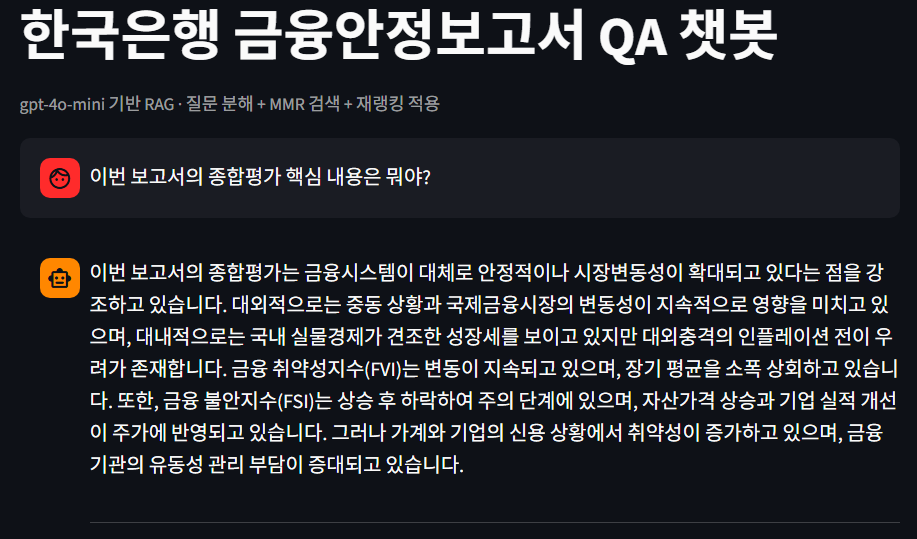

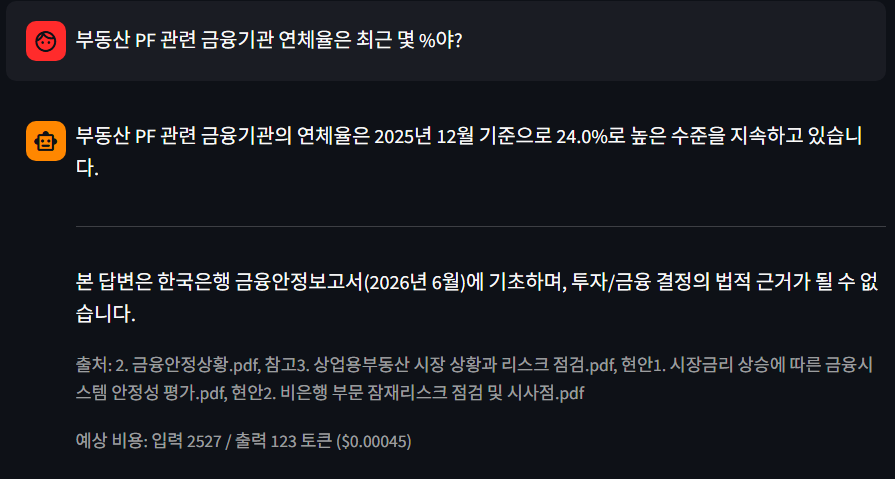

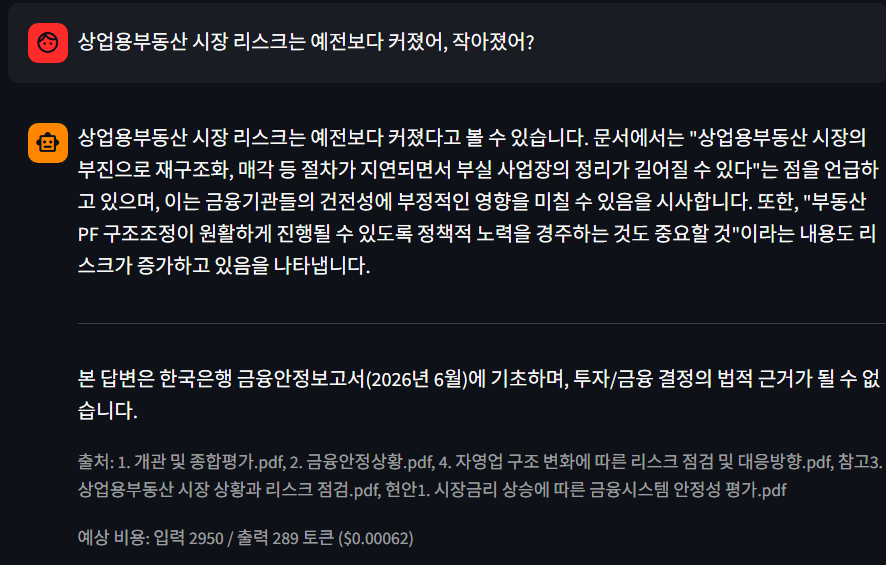

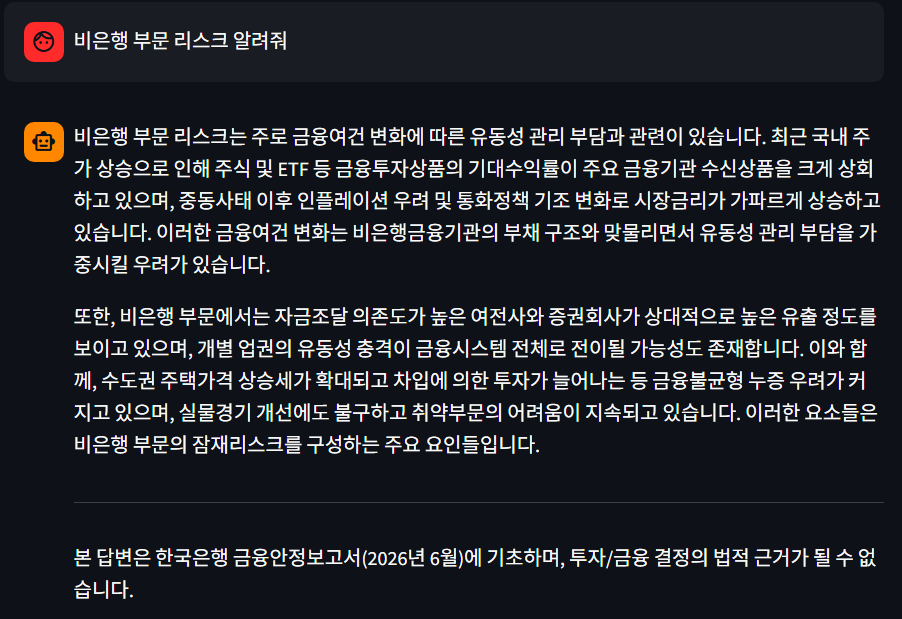

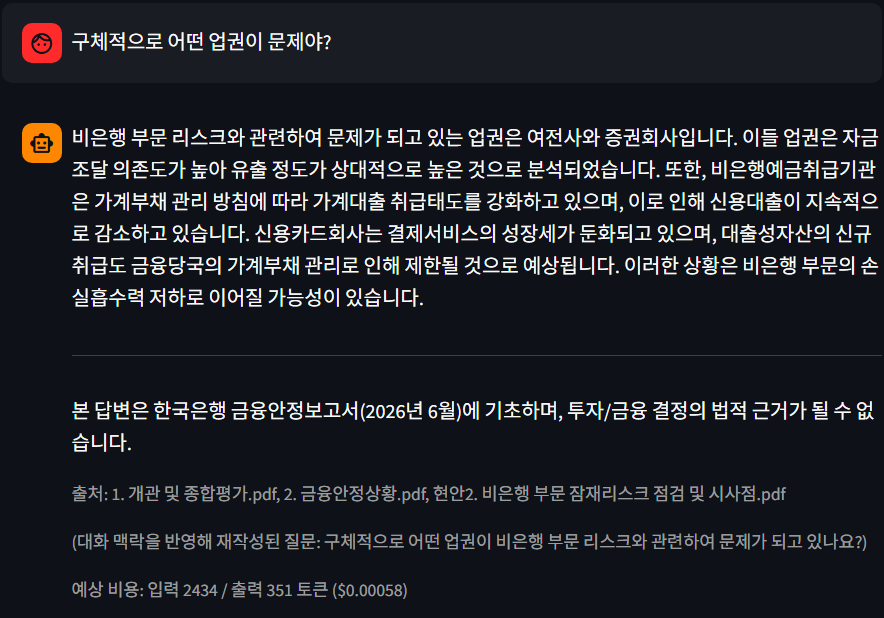